# Entrenamiento DQN

Deep Q-Network (DQN) con `stable-baselines3`. Red neuronal MLP procesa estado continuo.

Configuracion:
- 72,000 timesteps, num_seconds=100000
- Recompensa: multi-objetivo (-2.0*waiting + 1.5*throughput + 3.0*improvement + congestion)
- Entorno unico con **libsumo** (~8x mas rapido que traci puro)
- CheckpointCallback guarda modelo cada 18000 steps
- Red [128, 128] para estados continuos
- 12 acciones (duraciones de verde: 5, 10, 15, ..., 60 segundos)

In [ ]:
import os
import sys
import libsumo
import traci
import argparse
import pandas as pd
import sys
import numpy as np
import torch
torch._dynamo.config.suppress_errors = True

import gymnasium as gym
import seaborn as sns
import matplotlib.pyplot as plt

from sumo_rl import SumoEnvironment
from stable_baselines3 import DQN
from stable_baselines3.common.callbacks import CheckpointCallback

In [3]:
if 'SUMO_HOME' not in os.environ:
    os.environ['SUMO_HOME'] = '/usr/share/sumo'
tools = os.path.join(os.environ['SUMO_HOME'], 'tools')
sys.path.append(tools)

## Reward
Recompensa multi-objetivo basada en:
"Comparative Evaluation of Fuzzy Logic and Q-Learning for Adaptive Urban
Traffic Signal Control" (Electronics 2025, 14, 2759)
https://www.mdpi.com/2079-9292/14/14/2759

Reward con 4 componentes:

Formula: `-2.0*waiting + 1.5*throughput + 3.0*improvement + congestion`

Componentes:
- `waiting`: tiempo promedio de espera por vehiculo (penaliza)
- `throughput`: vehiculos que salieron de la red en este step (recompensa)
- `improvement`: reducción en tiempo de espera vs step anterior (recompensa)
- `congestion`: penalización fuerte (-100) si waiting > 9s AND queue > 61

In [4]:
class Reward:
    def __init__(self):
        self._prev = {'waiting': 0.0, 'veh_ids': set()}

    def reset(self):
        self._prev = {'waiting': 0.0, 'veh_ids': set()}

    def __call__(self, ts):
        ids = ts.sumo.vehicle.getIDList()
        waiting_time = np.mean([ts.sumo.vehicle.getWaitingTime(v) for v in ids]) if len(ids) > 0 else 0.0
        veh_ids_actuales = set(v for lane in ts.lanes for v in ts.sumo.lane.getLastStepVehicleIDs(lane))
        throughput = len(self._prev['veh_ids'] - veh_ids_actuales)
        queue = ts.get_total_queued()

        improvement = self._prev['waiting'] - waiting_time
        congestion = -100.0 if (waiting_time > 9 and queue > 61) else 0.0

        self._prev = {'waiting': waiting_time, 'veh_ids': veh_ids_actuales}
        return -2.0 * waiting_time + 1.5 * throughput + 3.0 * improvement + congestion

reward_fn = Reward()

## EarlyStopWrapper

Trunca el episodio cuando la red se vacia (no hay mas vehiculos).

- En simulaciones de trafico, el episodio naturalmente termina cuando
  no quedan vehiculos en la red
- Sin este wrapper, el episodio continuaria innecesariamente hasta num_seconds

In [5]:
class EarlyStopWrapper(gym.Wrapper):
    def __init__(self, env, reward_fn=None):
        super().__init__(env)
        self.reward_fn = reward_fn

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        if self.env.unwrapped.sumo.simulation.getMinExpectedNumber() == 0:
            truncated = True
        return obs, reward, terminated, truncated, info

    def reset(self, **kwargs):
        if self.reward_fn:
            self.reward_fn.reset()
        return self.env.reset(**kwargs)

In [6]:
NET = os.path.join("..", "Simple_Intersection.net.xml")
ROU = os.path.join("..", "Distribuciones", "loja_intersection_weibull.rou.xml")
OUT_FOLDER = "resultados"

os.makedirs(OUT_FOLDER, exist_ok=True)
os.makedirs(os.path.join(OUT_FOLDER, "mejores_pesos"), exist_ok=True)
os.makedirs(os.path.join(OUT_FOLDER, "logs"), exist_ok=True)
os.makedirs(os.path.join(OUT_FOLDER, "ultimo_pesos"), exist_ok=True)

print("NET existe:", os.path.exists(NET))
print("ROU existe:", os.path.exists(ROU))

NET existe: True
ROU existe: True


## VariableGreenWrapper

Seleccion de duracion de verde (5-60s en pasos de 5s) = 12 acciones.

Referencia:
- Paper original usa duraciones fijas de 45s. Este wrapper permite al agente
  seleccionar entre 12 duraciones (5, 10, 15, ..., 60 segundos).
- El wrapper alterna fases internamente (1 - fase_actual) y acumula
  recompensa durante la duracion seleccionada.

Por que 5-60s:
- Minimo 5s: tiempo minimo util para un ciclo de semaforo
- Maximo 60s: limite razonable para no bloquear interseccion
- Paso de 5s: balance entre granularidad y espacio de acciones

In [7]:
class VariableGreenWrapper(gym.Wrapper):
    DURACIONES = list(range(5, 65, 5))  # 12 acciones: 5-60s

    def __init__(self, env, delta_time=5):
        super().__init__(env)
        self.delta_time = delta_time
        self.action_space = gym.spaces.Discrete(len(self.DURACIONES))
        self._fase_actual = 0

    def step(self, action_idx):
        duracion = self.DURACIONES[action_idx]
        n_pasos = duracion // self.delta_time
        reward_acumulado = 0.0
        terminated = truncated = False
        info = {}
        for _ in range(n_pasos):
            obs, reward, terminated, truncated, info = self.env.step(self._fase_actual)
            reward_acumulado += reward
            if terminated or truncated:
                break
            if self.env.unwrapped.sumo.simulation.getMinExpectedNumber() == 0:
                break
        self._fase_actual = 1 - self._fase_actual
        return obs, reward_acumulado, terminated, truncated, info

    def reset(self, **kwargs):
        self._fase_actual = 0
        return self.env.reset(**kwargs)

In [8]:
def get_args():
    """
    Parametros de entrenamiento DQN con referencias bibliograficas.
    
    Referencias:
    - A Novel Deep Reinforcement Learning Approach to Traffic Signal Control (2023)
      https://doi.org/10.3390/app13042750
    - Enhancing traffic signal control with composite deep intelligence (2023)
      https://doi.org/10.1016/j.eswa.2023.123020
    - Adaptive Deep Q-Network Algorithm with Exponential Reward Mechanism (2022)
      https://doi.org/10.3390/su142114590
    - Deep Reinforcement Learning for Vehicle Platooning at a Signalized Intersection (2022)
      https://doi.org/10.3390/app121910145
    - An Adaptive Signal Control Model for Intersection Based on Deep RL Considering Carbon Emissions (2024)
      https://doi.org/10.3390/electronics14081664
    - Adaptive Traffic Signal Control Using Deep RL with Noise Injection (2024)
      https://doi.org/10.3390/app16083833
    - Deep Reinforcement Learning for Traffic Signal Control Model and Adaptation Study (2022)
      https://doi.org/10.3390/s22228732
    - An Enhanced Dueling Double DQN with CBAM for Traffic Signal Optimization (2024)
      https://doi.org/10.1109/ACCESS.2024.3380454
    """
    prs = argparse.ArgumentParser(formatter_class=argparse.ArgumentDefaultsHelpFormatter,
                                  description="""DQN Single-Intersection (Doble Recompensa)""")

    prs.add_argument("-route", dest="route", type=str, default=ROU)
    prs.add_argument("-net", dest="net", type=str, default=NET)
    prs.add_argument("-gui", action="store_true", default=False)
    
    # Total timesteps: 72000 pasos de entrenamiento totales.
    # Producto de 100 episodios de 3600 segundos con intervalos de decision de 5 segundos.
    # Ref: Traffic Signal Optimization for Multiple Intersect (2021)
    #      A Novel Deep Reinforcement Learning Approach to Traffic Signal Control (2023)
    prs.add_argument("-total_timesteps", dest="total_timesteps", type=int, default=72000)
    
    prs.add_argument("-num_seconds", dest="num_seconds", type=int, default=100000)

    # Learning rate: 1e-4 previene divergencias durante el descenso de gradiente
    # y garantiza una aproximacion estable de la funcion Q.
    # Ref: A Novel Deep Reinforcement Learning Approach (2023)
    #      Enhancing traffic signal control with composite deep intelligence (2024)
    prs.add_argument("-lr", dest="lr", type=float, default=1e-4)

    # Buffer de experiencia replay: 100000 transiciones maximas.
    # Evita descarte prematuro de experiencias y mitiga sobreajuste a estados recientes.
    # Ref: An Adaptive Signal Control Model Considering Carbon Emissions (2025)
    prs.add_argument("-buffer_size", dest="buffer_size", type=int, default=100000)

    # Pre-entrenamiento: 2000 pasos sin actualizar pesos.
    # Permite acumular varianza suficiente de estados antes de la primera iteracion.
    # Ref: A Novel Deep Reinforcement Learning Approach (2023)
    prs.add_argument("-learning_starts", dest="learning_starts", type=int, default=5000)

    # Batch size: 128 muestras por minilote.
    # Equilibra carga computacional con estimaciones de gradiente representativas.
    # Ref: An Adaptive Signal Control Model Considering Carbon Emissions (2025)
    prs.add_argument("-batch_size", dest="batch_size", type=int, default=128)

    # Target update: sincronizacion de red objetivo cada 1800 pasos.
    # Congela temporalmente la red objetivo para prevenir oscilaciones en el error TD.
    # Ref: Adaptive Deep Q-Network Algorithm (2022)
    prs.add_argument("-target_update", dest="target_update", type=int, default=1800)

    # Exploration fraction: decaimiento lineal a lo largo del 80% de los episodios.
    # Guia al modelo desde exploracion inicial hacia explotacion de politica optima.
    # Ref: Decentralized signal control for multi-modal traffic network (2023)
    prs.add_argument("-exploration_fraction", dest="exploration_fraction", type=float, default=0.8)

    # Exploration final epsilon: 5% de exploracion residual.
    # Previene convergencia a optimos locales y mantiene adaptabilidad.
    # Ref: An Adaptive Signal Control Model Considering Carbon Emissions (2025)
    prs.add_argument("-exploration_final_eps", dest="exploration_final_eps", type=float, default=0.05)

    return prs.parse_args(args=[])

## ProgressCallback

Callback personalizado para imprimir progreso del entrenamiento.

Muestra por cada episodio:
- Numero de episodio
- Recompensa acumulada
- Numero de steps
- Tiempo transcurrido

In [9]:
import time as time_mod
from stable_baselines3.common.callbacks import BaseCallback

class ProgressCallback(BaseCallback):
    def __init__(self):
        super().__init__()
        self.start_time = time_mod.time()
        self.episode_count = 0
        self.rewards = []
    
    def _on_step(self):
        infos = self.locals.get('infos', [{}])
        if isinstance(infos, list) and len(infos) > 0:
            info = infos[0]
            if 'episode' in info:
                self.episode_count += 1
                ep_reward = info['episode'].get('r', 0)
                ep_len = info['episode'].get('l', 0)
                elapsed = time_mod.time() - self.start_time
                self.rewards.append(ep_reward)
                print(f"  Ep {self.episode_count:3d} | Rec: {ep_reward:10.2f} | Steps: {ep_len:5d} | Time: {elapsed:.0f}s")
        return True

### Entrenamiento

In [60]:
args = get_args()

import sys as _sys
import os as _os
_old_stderr = _sys.stderr
_sys.stderr = open(_os.devnull, 'w')

env_train = SumoEnvironment(
    net_file=args.net,
    route_file=args.route,
    out_csv_name="temp",
    single_agent=True,
    use_gui=args.gui,
    num_seconds=args.num_seconds,
    reward_fn=reward_fn,
    time_to_teleport=-1,
    additional_sumo_cmd="-W --no-step-log"
)

_sys.stderr = _old_stderr

env_train = VariableGreenWrapper(env_train, delta_time=5)

env_train = EarlyStopWrapper(env_train, reward_fn=reward_fn)

model = DQN(
    "MlpPolicy",
    env_train,
    learning_rate=args.lr,
    buffer_size=args.buffer_size,
    learning_starts=args.learning_starts,
    batch_size=args.batch_size,
    gamma=0.99,
    target_update_interval=args.target_update,
    exploration_fraction=args.exploration_fraction,
    exploration_final_eps=args.exploration_final_eps,
    policy_kwargs=dict(net_arch=[128, 128]),
    verbose=0
)

checkpoint_cb = CheckpointCallback(
    save_freq=18000,
    save_path=os.path.join(OUT_FOLDER, 'mejores_pesos'),
    name_prefix='dqn_checkpoint'
)

try:
    print("Iniciando entrenamiento DQN...")
    progress_cb = ProgressCallback()
    model.learn(total_timesteps=args.total_timesteps, callback=[checkpoint_cb, progress_cb])

    model.save(os.path.join(OUT_FOLDER, "dqn_ultimo"))
    model.save(os.path.join(OUT_FOLDER, "best_model"))
    print(f"\nModelos guardados en {OUT_FOLDER}")
finally:
    env_train.close()
print("Entrenamiento finalizado.")

# Limpiar CSVs temporales de entrenamiento
import glob as _glob
for _f in _glob.glob("temp_*.csv"):
    os.remove(_f)

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 1ms, vehicles TOT 0 ACT 0 BUF 0)                      
Iniciando entrenamiento DQN...
 Retrying in 1 seconds
 Retrying in 1 seconds
  Ep   1 | Rec:  -11235.58 | Steps:   113 | Time: 15s
 Retrying in 1 seconds
  Ep   2 | Rec:  -14065.14 | Steps:   120 | Time: 29s
 Retrying in 1 seconds
  Ep   3 | Rec:   -8957.43 | Steps:   116 | Time: 44s
 Retrying in 1 seconds
  Ep   4 | Rec:  -15098.06 | Steps:   107 | Time: 58s
 Retrying in 1 seconds
  Ep   5 | Rec:   -9894.04 | Steps:   120 | Time: 72s
 Retrying in 1 seconds
  Ep   6 | Rec:  -12266.76 | Steps:   111 | Time: 86s
 Retrying in 1 seconds
  Ep   7 | Rec:  -10064.03 | Steps:   111 | Time: 101s
 Retrying in 1 seconds
  Ep   8 | Rec:  -13461.22 | Steps:   120 | Time: 115s
 Retrying in 1 seconds
  Ep   9 | Rec:  -11217.19 | Steps:   117 | Time: 129s
 Retrying in 1 seconds
  Ep  10 | Rec:  -10857.21 | Steps:   125 | Time: 144s
 Retrying in 1 seconds
  Ep  11 | Rec:  -11778.07 | Steps: 

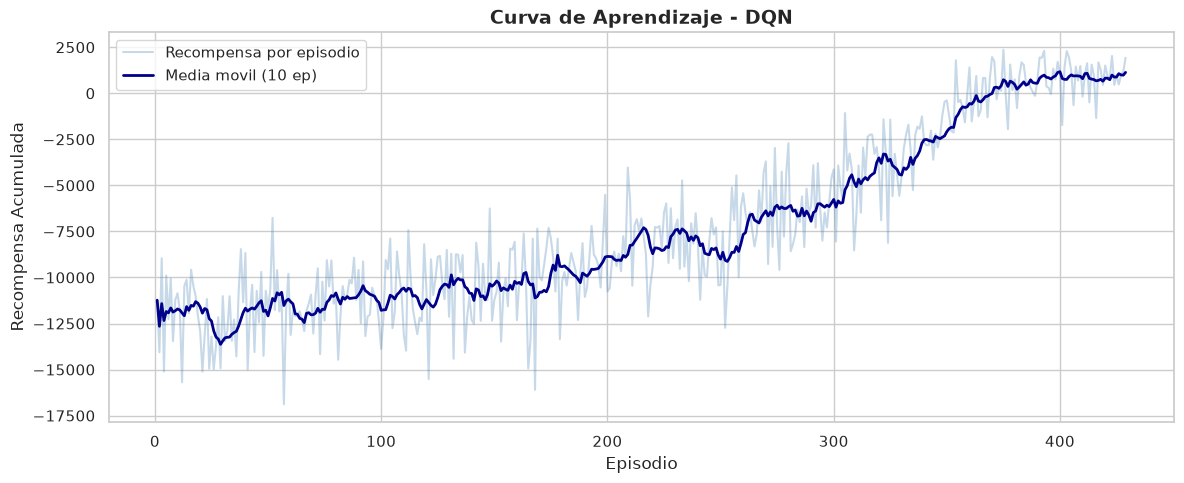

Episodios: 429
Mejor recompensa: 2357.82
Recompensa final (ultimos 10): 1132.47


In [62]:
# Curva de Aprendizaje
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 5))

rewards = progress_cb.rewards
episodes = range(1, len(rewards) + 1)
plt.plot(episodes, rewards, alpha=0.3, color='steelblue', label='Recompensa por episodio')

# Media movil (ventana de 10 episodios)
window = min(10, len(rewards))
media_movil = pd.Series(rewards).rolling(window=window, min_periods=1).mean()
plt.plot(episodes, media_movil, color='darkblue', linewidth=2, label=f'Media movil ({window} ep)')

plt.title('Curva de Aprendizaje - DQN', fontsize=14, fontweight='bold')
plt.xlabel('Episodio')
plt.ylabel('Recompensa Acumulada')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Episodios: {len(rewards)}")
print(f"Mejor recompensa: {max(rewards):.2f}")
print(f"Recompensa final (ultimos 10): {pd.Series(rewards).tail(10).mean():.2f}")

In [13]:
print("Cargando modelo")
model = DQN.load(os.path.join(OUT_FOLDER, "dqn_ultimo"))

args = get_args()

env_eval = SumoEnvironment(
    net_file=args.net,
    route_file=args.route,
    out_csv_name=os.path.join(OUT_FOLDER, 'evaluacion_final'),
    single_agent=True,
    use_gui=True,
    num_seconds=args.num_seconds,
    time_to_teleport=-1,
    additional_sumo_cmd=f"-W --no-step-log --tripinfo-output {os.path.join(OUT_FOLDER, 'tripinfo.xml')}"
)

env_eval = VariableGreenWrapper(env_eval, delta_time=5)

obs, _ = env_eval.reset()
try:
    done = False
    datos_recolectados = []

    print("Evaluacion")

    while not done:
        action, _states = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = env_eval.step(action)
        datos_recolectados.append(info)

        if env_eval.unwrapped.sumo.simulation.getMinExpectedNumber() == 0:
            tiempo_final = env_eval.unwrapped.sim_step
            print(f"Evaluacion completada. Red vaciada en {tiempo_final:.1f}s")
            break

        done = terminated or truncated

finally:
    env_eval.close()

df_metricas = pd.DataFrame(datos_recolectados)
ruta_csv = os.path.join(OUT_FOLDER, "metricas.csv")
os.makedirs(OUT_FOLDER, exist_ok=True)
df_metricas.to_csv(ruta_csv, index=False)

print(f"CSV exportado: {ruta_csv}")
print(f"XML generado: {os.path.join(OUT_FOLDER, 'tripinfo.xml')}")

Cargando modelo
 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 1ms, vehicles TOT 0 ACT 0 BUF 0)                      
 Retrying in 1 seconds
Evaluacion
Evaluacion completada. Red vaciada en 3830.0s
CSV exportado: resultados/metricas.csv
XML generado: resultados/tripinfo.xml


In [14]:
df_metricas = pd.read_csv(os.path.join(OUT_FOLDER, "metricas.csv"))
print(f"Registros cargados: {len(df_metricas)}")

Registros cargados: 246


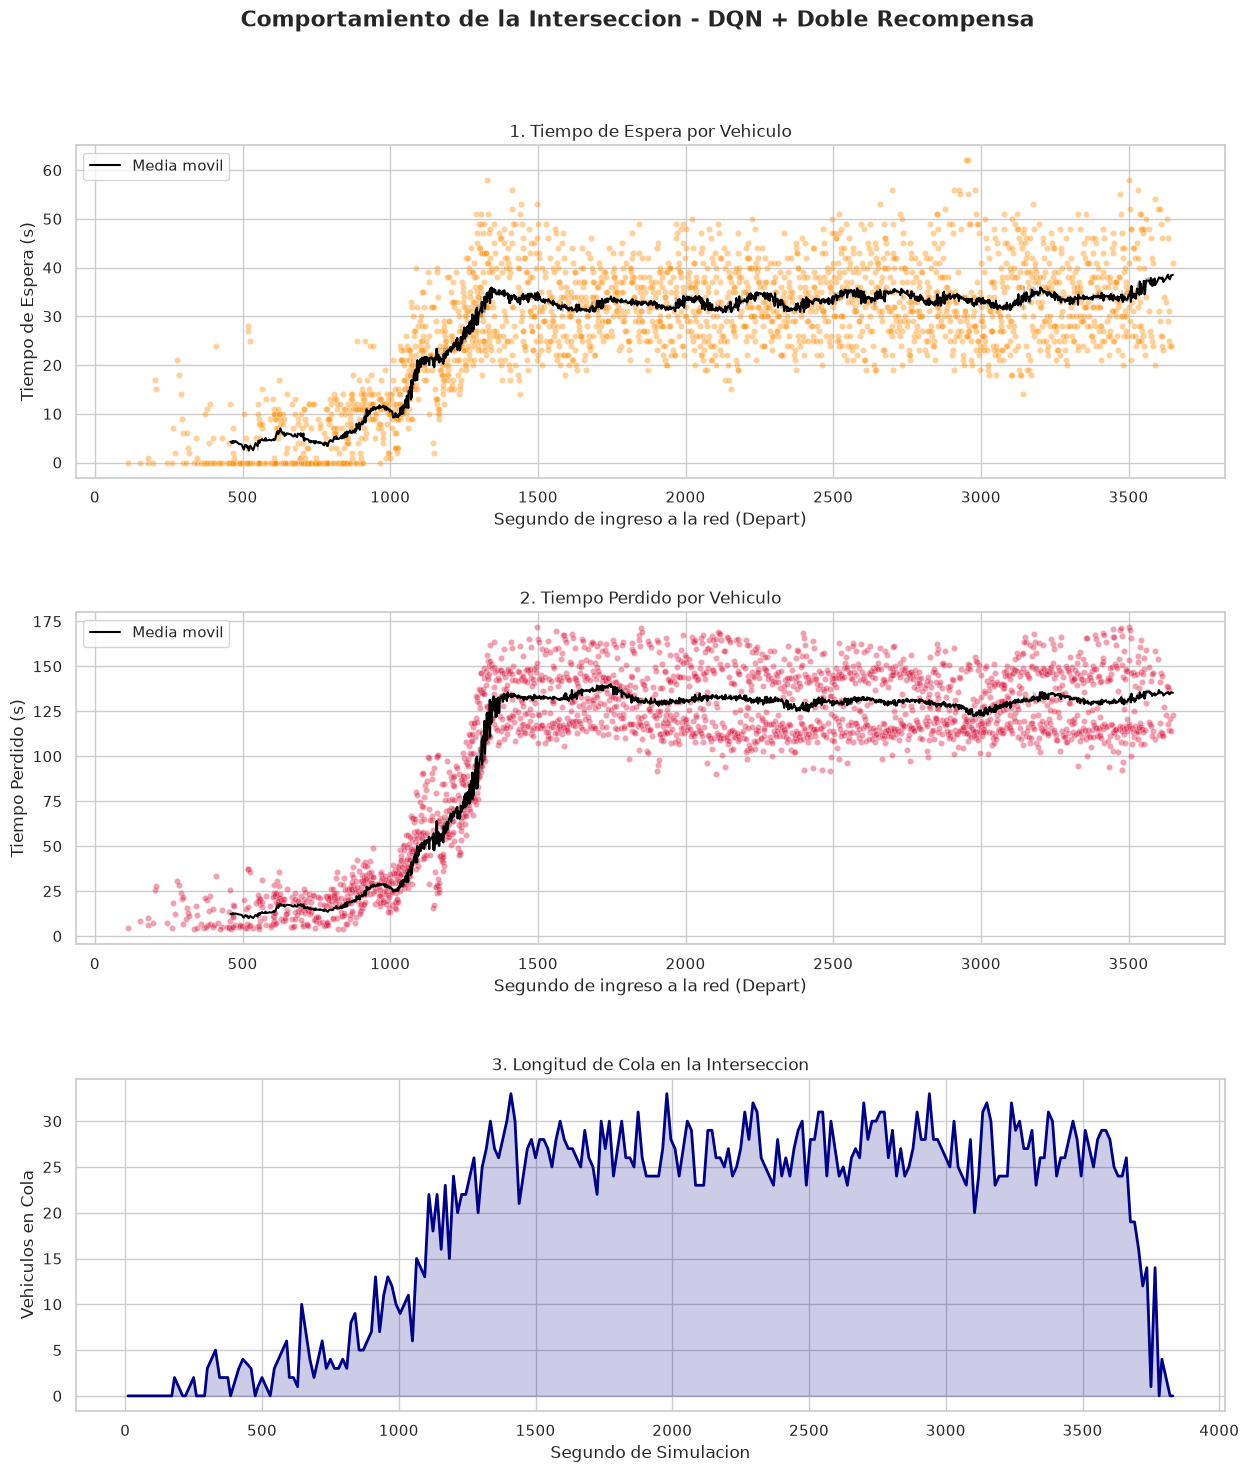

In [15]:
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

ruta_xml = os.path.join(OUT_FOLDER, "tripinfo.xml")
df_trips = pd.read_xml(ruta_xml)

for col in ['depart', 'waitingTime', 'timeLoss']:
    df_trips[col] = pd.to_numeric(df_trips[col])

fig, axs = plt.subplots(3, 1, figsize=(14, 15))
fig.tight_layout(pad=6.0)
fig.suptitle('Comportamiento de la Interseccion - DQN + Doble Recompensa', fontsize=16, fontweight='bold', y=1.02)

sns.scatterplot(x=df_trips['depart'], y=df_trips['waitingTime'], alpha=0.4, color='darkorange', s=20, ax=axs[0])
sns.lineplot(x=df_trips['depart'], y=df_trips['waitingTime'].rolling(50).mean(), color='black', label='Media movil', ax=axs[0])
axs[0].set_title("1. Tiempo de Espera por Vehiculo")
axs[0].set_xlabel("Segundo de ingreso a la red (Depart)")
axs[0].set_ylabel("Tiempo de Espera (s)")
axs[0].legend()

sns.scatterplot(x=df_trips['depart'], y=df_trips['timeLoss'], alpha=0.4, color='crimson', s=20, ax=axs[1])
sns.lineplot(x=df_trips['depart'], y=df_trips['timeLoss'].rolling(50).mean(), color='black', label='Media movil', ax=axs[1])
axs[1].set_title("2. Tiempo Perdido por Vehiculo")
axs[1].set_xlabel("Segundo de ingreso a la red (Depart)")
axs[1].set_ylabel("Tiempo Perdido (s)")
axs[1].legend()

axs[2].plot(df_metricas['step'], df_metricas['system_total_stopped'], color='darkblue', linewidth=2)
axs[2].fill_between(df_metricas['step'], df_metricas['system_total_stopped'], color='darkblue', alpha=0.2)
axs[2].set_title("3. Longitud de Cola en la Interseccion")
axs[2].set_xlabel("Segundo de Simulacion")
axs[2].set_ylabel("Vehiculos en Cola")

plt.show()

In [67]:
for col in ['waitingTime', 'timeLoss', 'routeLength', 'duration']:
    df_trips[col] = pd.to_numeric(df_trips[col])

df_trips['velocidad_kmh'] = (df_trips['routeLength'] / df_trips['duration']) * 3.6

promedio_espera = df_trips['waitingTime'].mean()
maximo_espera = df_trips['waitingTime'].max()
promedio_perdido = df_trips['timeLoss'].mean()
maximo_perdido = df_trips['timeLoss'].max()
velocidad_media = df_trips['velocidad_kmh'].mean()
total_vehiculos = len(df_trips)
cola_promedio = df_metricas['system_total_stopped'].mean()
cola_maxima = df_metricas['system_total_stopped'].max()

print("=" * 50)
print("  REPORTE DE METRICAS: DQN + DOBLE RECOMPENSA")
print("=" * 50)
print("\n--- Rendimiento General ---")
print(f"Total de vehiculos procesados : {total_vehiculos}")
print(f"Velocidad promedio del sistema: {velocidad_media:.2f} km/h")

print("\n--- Demora Vehicular (Tripinfo) ---")
print(f"Tiempo de espera promedio     : {promedio_espera:.2f} s")
print(f"Tiempo de espera MAXIMO       : {maximo_espera:.2f} s")
print(f"Tiempo perdido promedio       : {promedio_perdido:.2f} s")
print(f"Tiempo perdido MAXIMO         : {maximo_perdido:.2f} s")

print("\n--- Ocupacion de la Interseccion (TraCI) ---")
print(f"Longitud de cola promedio     : {cola_promedio:.2f} vehiculos")
print(f"Longitud de cola MAXIMA       : {cola_maxima} vehiculos")
print("=" * 50)
display(df_trips[['id', 'depart', 'duration', 'waitingTime', 'timeLoss']].head())

  REPORTE DE METRICAS: DQN + DOBLE RECOMPENSA

--- Rendimiento General ---
Total de vehiculos procesados : 2418
Velocidad promedio del sistema: 16.91 km/h

--- Demora Vehicular (Tripinfo) ---
Tiempo de espera promedio     : 27.99 s
Tiempo de espera MAXIMO       : 59.00 s
Tiempo perdido promedio       : 104.96 s
Tiempo perdido MAXIMO         : 174.60 s

--- Ocupacion de la Interseccion (TraCI) ---
Longitud de cola promedio     : 19.63 vehiculos
Longitud de cola MAXIMA       : 34 vehiculos


,id,depart,duration,waitingTime,timeLoss
0,veh_0,112.0,49.0,0.0,5.11
1,veh_1,154.0,54.0,0.0,9.79
2,veh_2,179.0,52.0,0.0,6.78
3,veh_3,179.0,63.0,3.0,12.34
4,veh_4,195.0,53.0,0.0,6.02
